<a href="https://colab.research.google.com/github/zeynepuygrr/softito_hw/blob/main/23_09_2026odev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Musteri Segmentasyonu ve Churn Tahmini
Bu notebook, derste islenen kumeleme + siniflandirma pipeline'inin kendi secilen veri setleriyle uygulanmasidir.
- **Kumeleme:** Mall Customers veri seti (musteri segmentasyonu)
- **Siniflandirma:** Telco Customer Churn veri seti (musteri kaybi tahmini)

## 1. Kutuphaneler

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage


## 2. Kumeleme - Mall Customers Veri Seti
Musterileri yas, yillik gelir ve harcama skoruna gore segmentlere ayiracagiz.

In [ ]:
df = pd.read_csv("Mall_Customers.csv")
print(f"veri boyutu:{df.shape}")
df.info()


veri boyutu:(200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [ ]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [ ]:
df.head(2)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81


In [ ]:
df.set_index("CustomerID", inplace=True)

# Gender'i sayisala cevir
df["Gender"] = LabelEncoder().fit_transform(df["Gender"])  # Female=0, Male=1

imputer = SimpleImputer(strategy="mean")
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)
print(f"Eksik deger kaldi mi: {df_imputed.isnull().sum().sum()}")


Eksik deger kaldi mi: 0


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)
df_scaled = pd.DataFrame(X_scaled, columns=df_imputed.columns, index=df_imputed.index)
df_scaled.head(2)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,1.128152,-1.424569,-1.738999,-0.434801
2,1.128152,-1.281035,-1.738999,1.195704


### 2.1 Optimum K Degeri - Elbow ve Silhouette

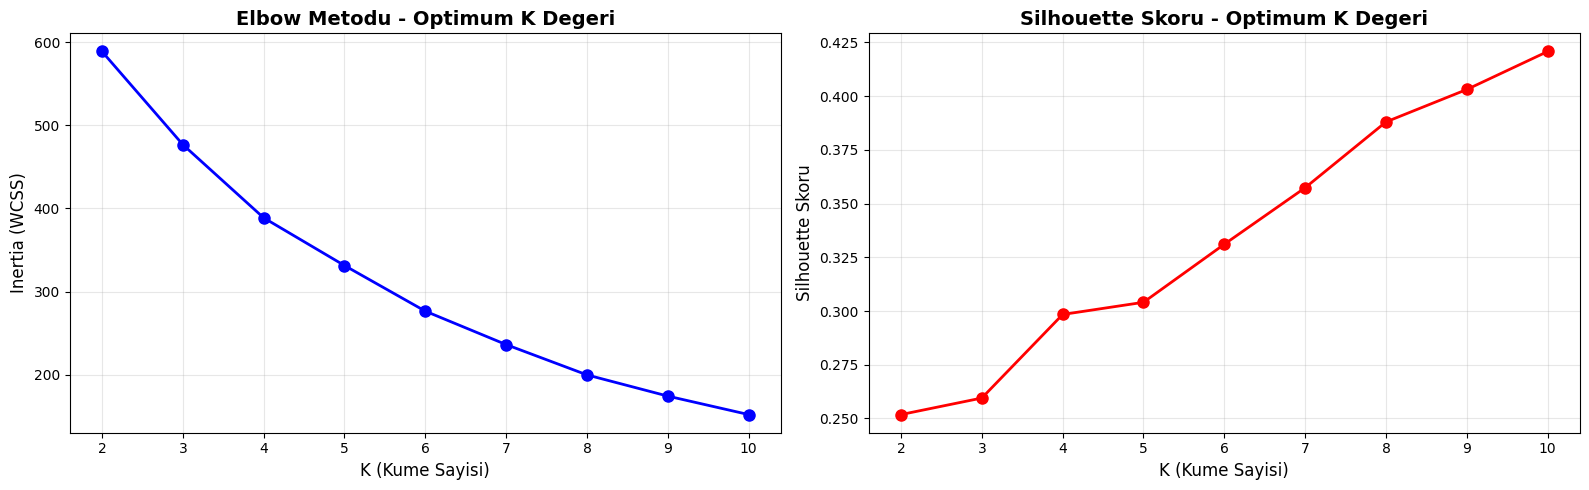

En iyi silhouette skoru: 0.4208
Optimum K degeri: 10


In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Metodu - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[0].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Skoru - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[1].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[1].set_ylabel('Silhouette Skoru', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150)
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhouette skoru: {max(silhouette_scores):.4f}')
print(f'Optimum K degeri: {optimal_k}')


### 2.2 K-Means Kumeleme

In [ ]:
optimal_k = 5  # Elbow ve silhouette analizine gore (Mall Customers icin klasik sonuc)
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print('K-Means Kumeleme Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(kmeans_labels).value_counts().sort_index())


K-Means Kumeleme Sonuclari:
Kume sayisi: 5
Silhouette Skoru: 0.3041
Davies-Bouldin Indeksi: 1.1672
Calinski-Harabasz Skoru: 68.9646

Kume dagilimi:
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64


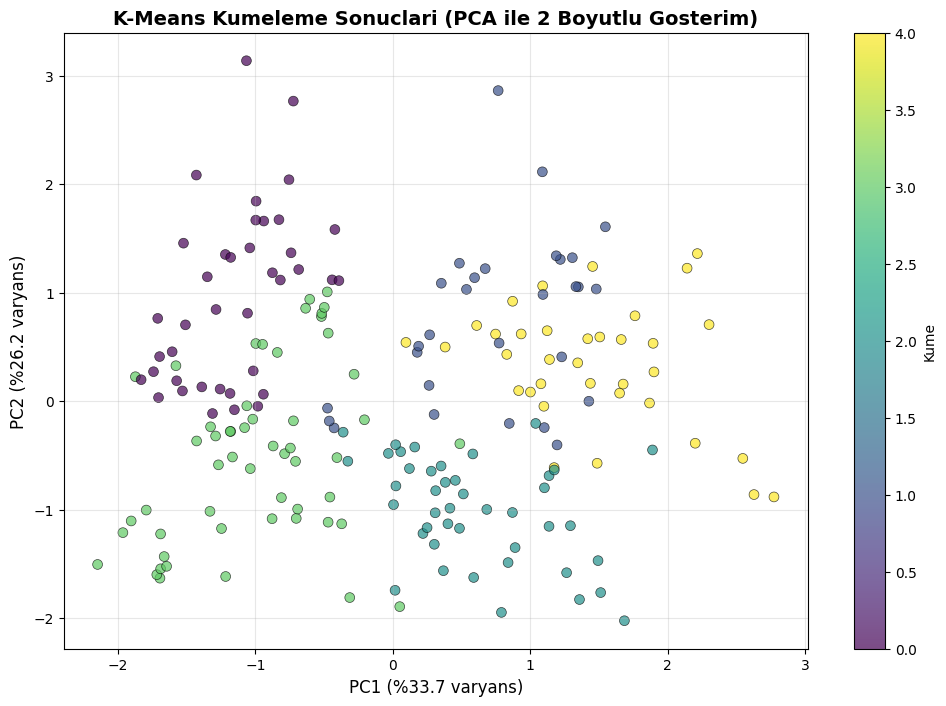

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('K-Means Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig("kmeans_pca.png", dpi=150)
plt.show()


### 2.3 Hiyerarsik Kumeleme

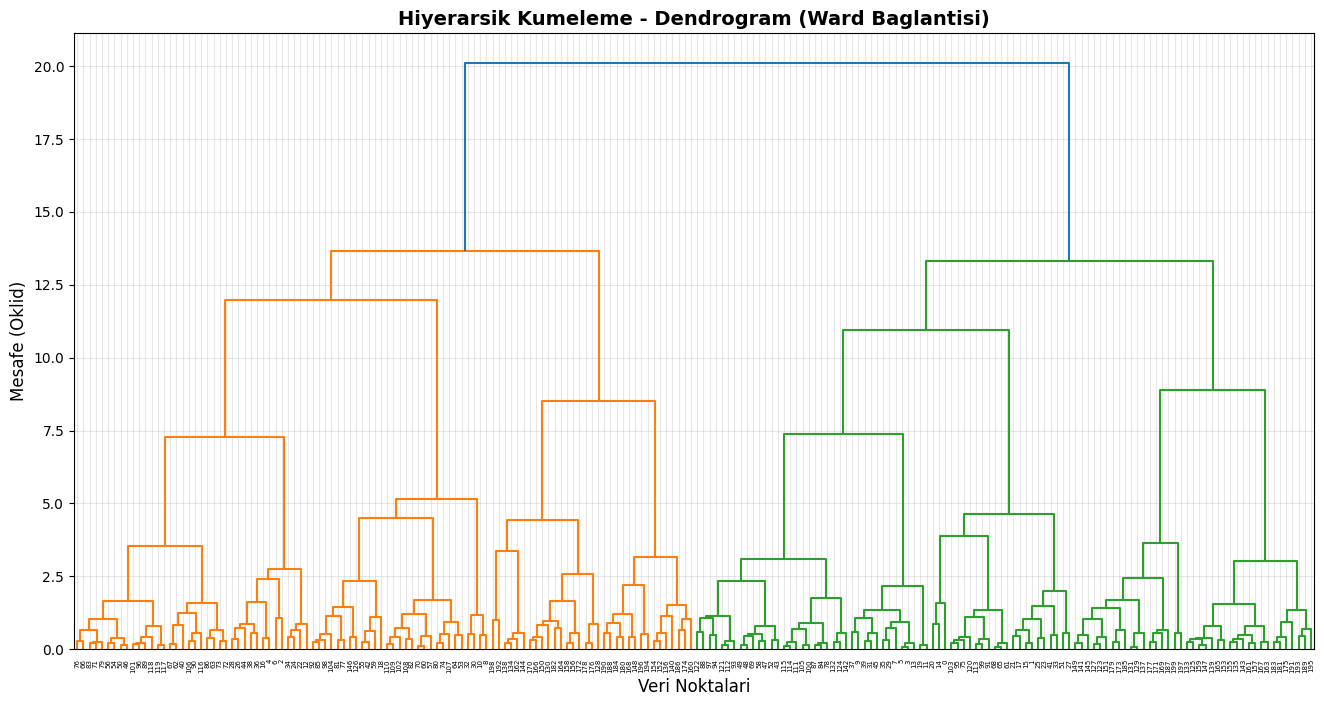

In [ ]:
plt.figure(figsize=(16, 8))
linked = linkage(X_scaled, method='ward')
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=False, truncate_mode='level', p=10)
plt.title('Hiyerarsik Kumeleme - Dendrogram (Ward Baglantisi)', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari', fontsize=12)
plt.ylabel('Mesafe (Oklid)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig("dendrogram.png", dpi=150)
plt.show()


In [ ]:
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

print('Hiyerarsik Kumeleme (Agglomerative) Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Baglanti yontemi: ward')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, agg_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, agg_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, agg_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(agg_labels).value_counts().sort_index())


Hiyerarsik Kumeleme (Agglomerative) Sonuclari:
Kume sayisi: 5
Baglanti yontemi: ward
Silhouette Skoru: 0.2870
Davies-Bouldin Indeksi: 1.2198
Calinski-Harabasz Skoru: 64.4687

Kume dagilimi:
0    61
1    39
2    33
3    38
4    29
Name: count, dtype: int64


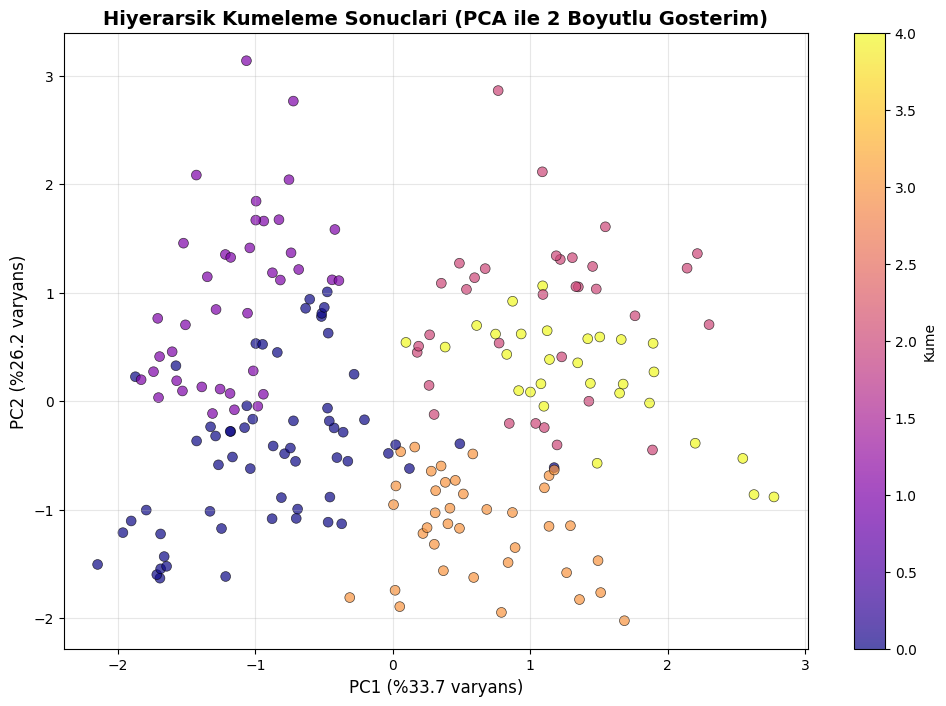

In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('Hiyerarsik Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig("agg_pca.png", dpi=150)
plt.show()


### 2.4 DBSCAN

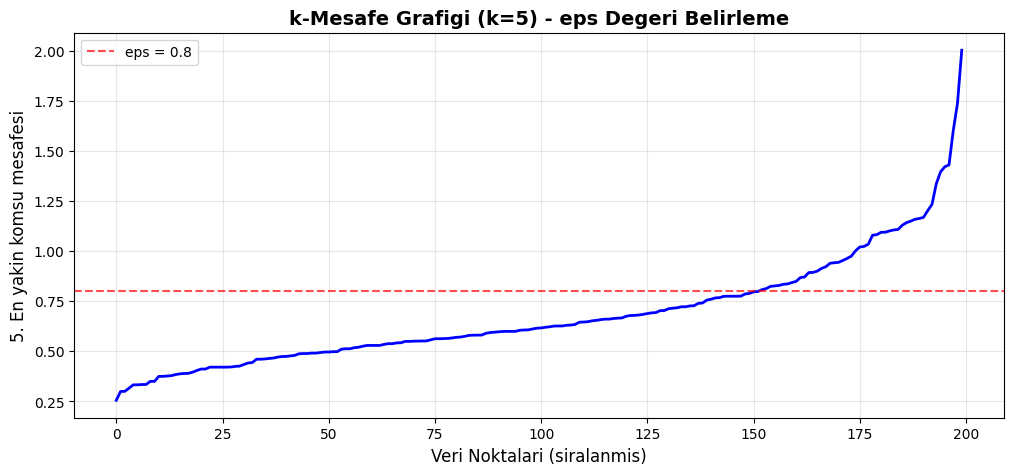

In [ ]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafigi (k=5) - eps Degeri Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari (siralanmis)', fontsize=12)
plt.ylabel('5. En yakin komsu mesafesi', fontsize=12)
plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='eps = 0.8')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("dbscan_kdist.png", dpi=150)
plt.show()


In [ ]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print('DBSCAN Kumeleme Sonuclari:')
print(f'eps: 0.8, min_samples: 5')
print(f'Olusan kume sayisi: {n_clusters_db}')
print(f'Gurultu (aykiri deger) sayisi: {n_noise}')
print(f'Gurultu orani: {n_noise/len(dbscan_labels)*100:.2f}%')

if n_clusters_db > 1:
    print(f'Silhouette Skoru: {silhouette_score(X_scaled, dbscan_labels):.4f}')
    print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, dbscan_labels):.4f}')
    print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, dbscan_labels):.4f}')

print(f'\nKume dagilimi:')
print(pd.Series(dbscan_labels).value_counts().sort_index())


DBSCAN Kumeleme Sonuclari:
eps: 0.8, min_samples: 5
Olusan kume sayisi: 5
Gurultu (aykiri deger) sayisi: 19
Gurultu orani: 9.50%
Silhouette Skoru: 0.1721
Davies-Bouldin Indeksi: 2.7362
Calinski-Harabasz Skoru: 28.7479

Kume dagilimi:
-1    19
 0     9
 1    94
 2    40
 3    26
 4    12
Name: count, dtype: int64


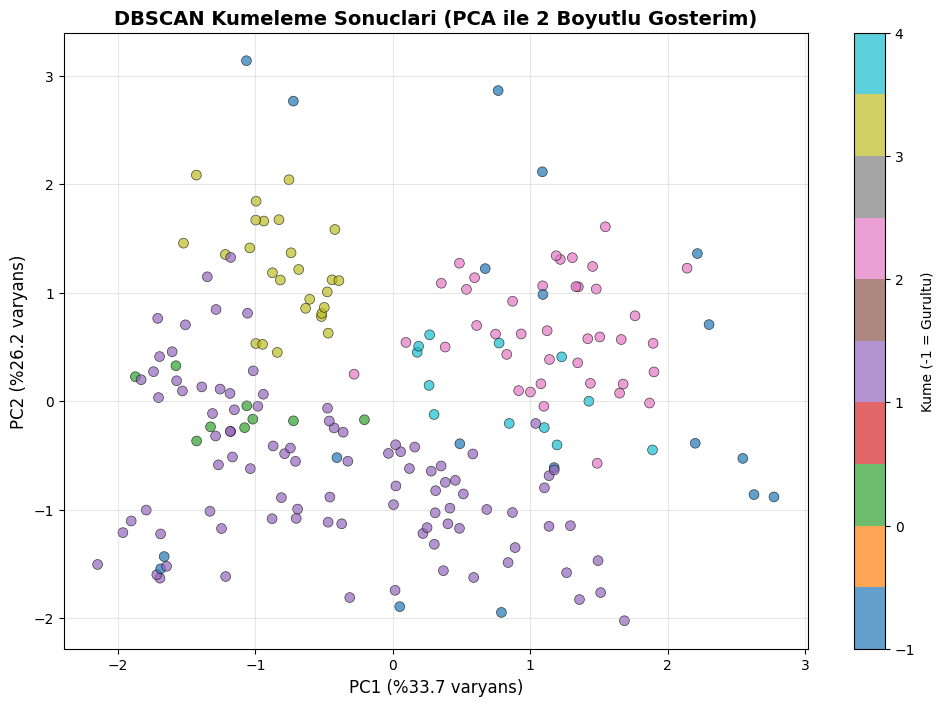

In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume (-1 = Gurultu)')
plt.title('DBSCAN Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig("dbscan_pca.png", dpi=150)
plt.show()


## **Decision Tree ve Random Forest**

In [ ]:
import random
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay


### 3.1 Telco Customer Churn Veri Seti - On Isleme
Musterinin abonelikten ayrilip ayrilmayacagini (Churn) tahmin edecegiz.

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

churn_df = pd.read_csv("Telco-Customer-Churn.csv")
print(f"veri boyutu:{churn_df.shape}")
churn_df.info()


veri boyutu:(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nul

In [ ]:
churn_df.drop(columns=["customerID"], inplace=True)

# TotalCharges bos stringleri var, sayisala cevirip eksikleri dolduruyoruz
churn_df["TotalCharges"] = pd.to_numeric(churn_df["TotalCharges"], errors="coerce")
churn_df["TotalCharges"].fillna(churn_df["TotalCharges"].median(), inplace=True)

# Hedef degisken
y = LabelEncoder().fit_transform(churn_df["Churn"])  # No=0, Yes=1
churn_features = churn_df.drop(columns=["Churn"])

# Kategorik sutunlari one-hot encode ediyoruz
churn_features = pd.get_dummies(churn_features, drop_first=True)
feature_names = churn_features.columns
X = churn_features.values

print(f"Ozellik sayisi: {X.shape[1]}")
print(f"Sinif dagilimi:\n{pd.Series(y).value_counts()}")


Ozellik sayisi: 30
Sinif dagilimi:
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)


### 3.2 Decision Tree - GridSearchCV

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=SEED),
                      param_grid={
                          "criterion": ["gini", "entropy"],
                          "splitter": ["best", "random"],
                          "max_depth": [3, 4, 5, 6, 8, None],
                          "min_samples_leaf": [1, 2, 5, 10]
                      },
                      cv=cv, scoring="accuracy", n_jobs=-1)
dt_grid.fit(X_train, y_train)
dt = dt_grid.best_estimator_
print("En iyi parametre:", dt_grid.best_params_)


En iyi parametre: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'splitter': 'best'}


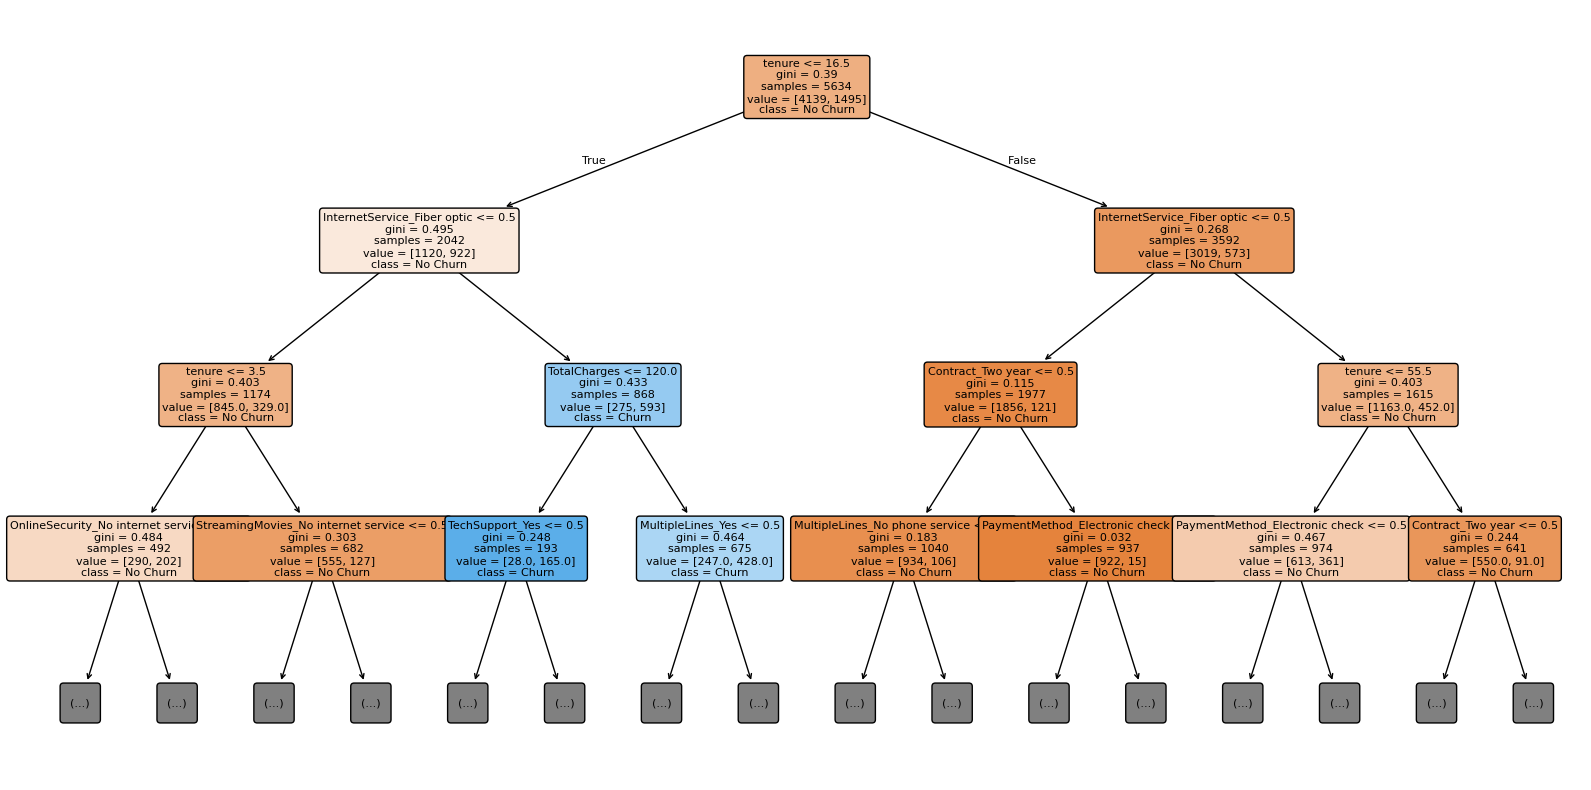

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=feature_names, class_names=["No Churn", "Churn"],
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.savefig("decision_tree.png", dpi=150)
plt.show()


### 3.3 Random Forest - GridSearchCV

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_grid = GridSearchCV(RandomForestClassifier(random_state=SEED),
                      param_grid={
                          "n_estimators": [100, 200],
                          "max_depth": [5, 7],
                          "min_samples_leaf": [1, 2],
                          "min_samples_split": [2, 5],
                          "max_features": ["sqrt", "log2"],
                          "criterion": ["gini", "entropy"],
                          "bootstrap": [True, False]
                      },
                      cv=cv, scoring="accuracy", n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_
print("En iyi parametre:", rf_grid.best_params_)


En iyi parametre: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


### 3.4 Model Karsilastirma

In [ ]:
results = {}
for name, model in [("Decision Tree", dt), ("Random Forest", rf)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    results[name] = accuracy_score(y_test, y_pred)
    print(f"======== {name} ========")
    print(f"Test dogrulugu: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Ortalama 5 katli CV dogrulugu: {np.mean(cv_scores):.4f}")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


======== Decision Tree ========
Test dogrulugu: 0.7942
Ortalama 5 katli CV dogrulugu: 0.7904
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



======== Random Forest ========
Test dogrulugu: 0.8020
Ortalama 5 katli CV dogrulugu: 0.8032
              precision    recall  f1-score   support

    No Churn       0.83      0.92      0.87      1035
       Churn       0.68      0.47      0.56       374

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



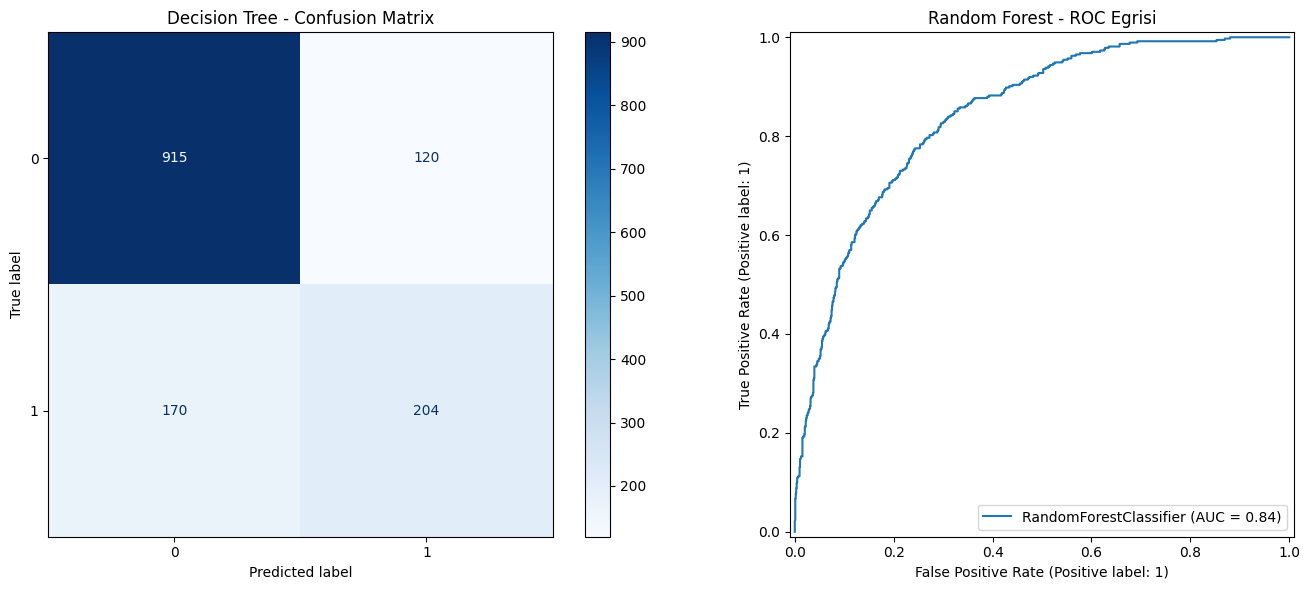

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, ax=axes[0], cmap="Blues")
axes[0].set_title("Decision Tree - Confusion Matrix")
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=axes[1])
axes[1].set_title("Random Forest - ROC Egrisi")
plt.tight_layout()
plt.savefig("confusion_roc.png", dpi=150)
plt.show()


### 3.5 Ozellik Onemi (Random Forest)

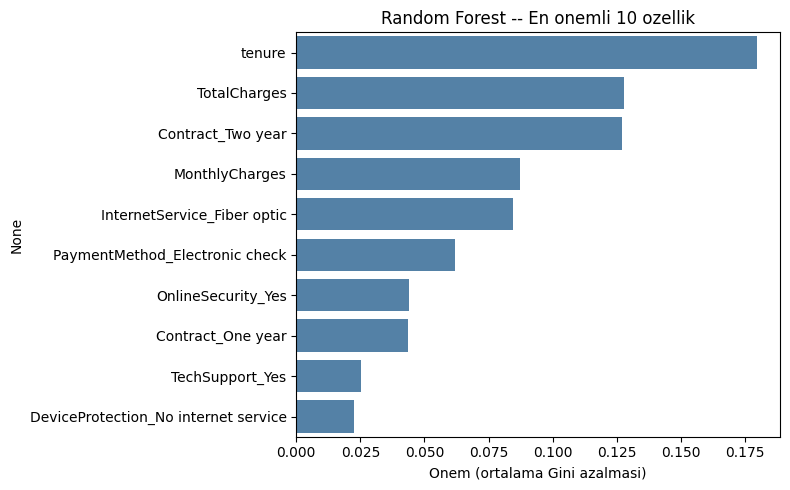

Grafikler kaydedildi: decision_tree.png, confusion_roc.png, feature_importance.png


In [ ]:
imp = pd.Series(rf.feature_importances_, index=feature_names).nlargest(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.xlabel("Onem (ortalama Gini azalmasi)")
plt.title("Random Forest -- En onemli 10 ozellik")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("Grafikler kaydedildi: decision_tree.png, confusion_roc.png, feature_importance.png")
